In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.io import resolve_relative_path
from src.climate_stats import kde_1d

In [2]:
monthly_climatology = pd.read_csv(
    resolve_relative_path("data/processed/monthly_station_climatology.csv")
)

monthly_climatology

,month,month_name,precip_mean_mm,precip_std_mm,temp_mean_C,temp_std_C,snow_mean_cm,snow_max_cm,n_years
0,1,January,14.646429,8.520046,-26.619527,4.199473,31.783798,37.200000,84
1,2,February,11.703571,6.548714,-24.212752,4.114606,38.000099,42.436620,84
2,3,March,11.388095,8.567400,-17.708455,3.487436,40.366386,45.930556,84
3,4,April,9.832143,6.854445,-6.357527,3.467832,23.961377,39.000000,84
4,5,May,15.879518,12.129110,5.042976,2.587179,1.104346,5.681818,83
5,6,June,23.610843,19.719020,13.165437,1.593175,0.000000,0.000000,83
6,7,July,35.503571,24.472933,16.617361,1.315769,0.000000,0.000000,84
7,8,August,39.271429,28.534463,14.320622,1.527542,0.000000,0.000000,84
8,9,September,32.025000,18.189656,7.364951,1.897107,0.263743,1.350877,84
9,10,October,29.652381,15.237766,-1.121027,2.215901,2.903905,9.228571,84


### Uncertainty assumptions

* Monthly precipitation totals are represented by normal distributions defined by historical mean and standard deviation, truncated at zero.
* Monthly mean temperature is represented by a normal distribution defined by historical mean and standard deviation.
* Monthly values are treated as statistically independent for Monte Carlo sampling.

In [3]:
months = monthly_climatology["month_name"]

precip_mu = monthly_climatology["precip_mean_mm"].values
precip_sigma = monthly_climatology["precip_std_mm"].values

temp_mu = monthly_climatology["temp_mean_C"].values
temp_sigma = monthly_climatology["temp_std_C"].values

10,000 samples

In [4]:
n_samples = 10_000

# Precipitation sampling (truncate at zero)
precip_samples = np.maximum(
    0,
    np.random.normal(
        loc=precip_mu,
        scale=precip_sigma,
        size=(n_samples, len(precip_mu))
    )
)

# Temperature sampling
temp_samples = np.random.normal(
    loc=temp_mu,
    scale=temp_sigma,
    size=(n_samples, len(temp_mu))
)

precip_samples.shape, temp_samples.shape

((10000, 12), (10000, 12))

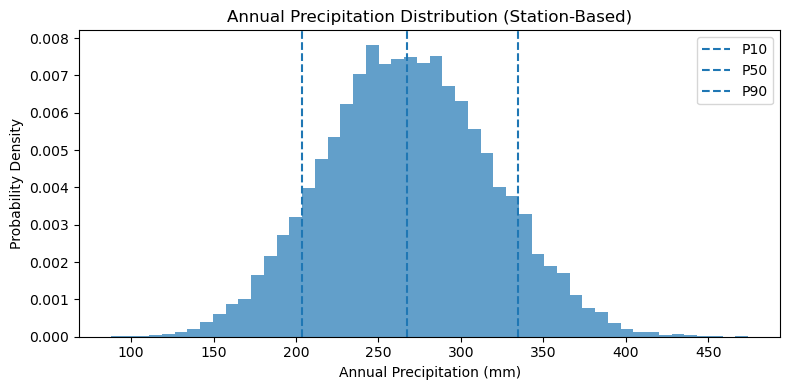

In [5]:
annual_precip = precip_samples.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(annual_precip, bins=50, density=True, alpha=0.7)
plt.axvline(np.percentile(annual_precip, 10), linestyle="--", label="P10")
plt.axvline(np.percentile(annual_precip, 50), linestyle="--", label="P50")
plt.axvline(np.percentile(annual_precip, 90), linestyle="--", label="P90")
plt.xlabel("Annual Precipitation (mm)")
plt.ylabel("Probability Density")
plt.title("Annual Precipitation Distribution (Station-Based)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
p10, p50, p90 = np.percentile(annual_precip, [10, 50, 90])

pd.DataFrame(
    {
        "Percentile": ["P10", "P50", "P90"],
        "Annual Precipitation (mm)": [p10, p50, p90],
    }
)

,Percentile,Annual Precipitation (mm)
0,P10,203.337416
1,P50,267.276467
2,P90,334.473505


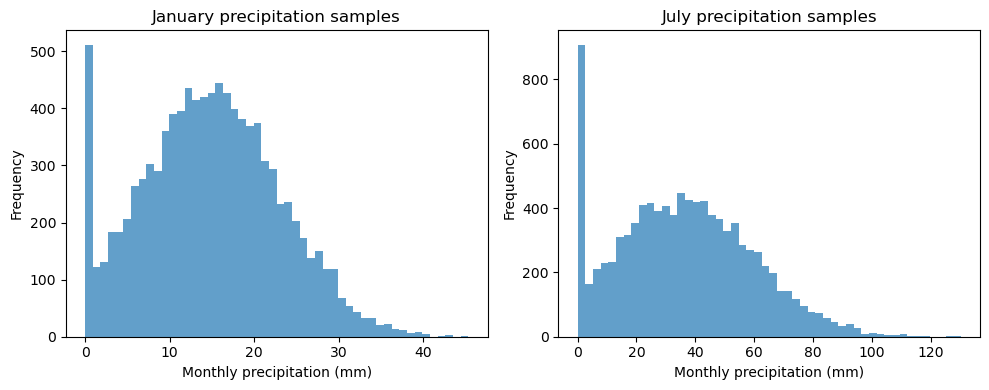

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# January precipitation
ax[0].hist(precip_samples[:, 0], bins=50, alpha=0.7)
ax[0].set_title("January precipitation samples")

# July precipitation
ax[1].hist(precip_samples[:, 6], bins=50, alpha=0.7)
ax[1].set_title("July precipitation samples")

for a in ax:
    a.set_xlabel("Monthly precipitation (mm)")
    a.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Compare to observed monthly data

In [8]:
monthly_by_year = pd.read_csv(
    resolve_relative_path("data/processed/monthly_station_by_year.csv")
)

In [9]:
obs_jan = monthly_by_year.loc[
    monthly_by_year["month"] == 1, "precip_mm"
]

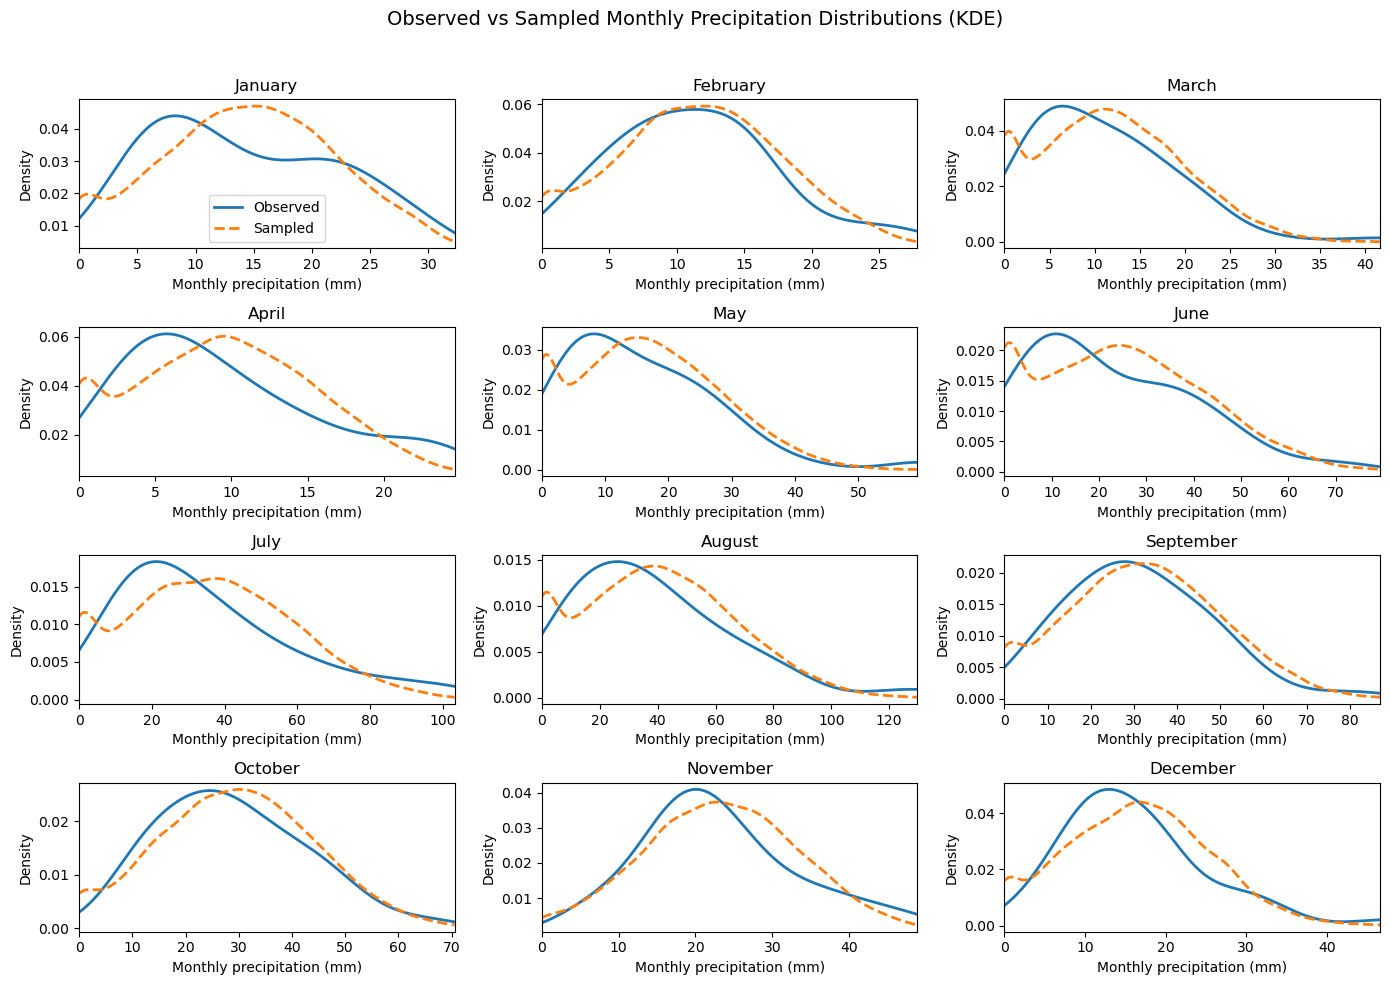

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    # Observed monthly precipitation
    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    # Sampled monthly precipitation
    samp = precip_samples[:, i]

    # Define x-axis range based on observed distribution
    xmax = np.percentile(obs, 99)
    xgrid = np.linspace(0, xmax, 300)

    # KDEs
    obs_kde = kde_1d(obs, xgrid)
    samp_kde = kde_1d(samp, xgrid)

    ax = axes[i]
    ax.plot(xgrid, obs_kde, label="Observed", linewidth=2)
    ax.plot(
        xgrid,
        samp_kde,
        label="Sampled",
        linestyle="--",
        linewidth=2
    )

    ax.set_xlim(0, xmax)
    ax.set_title(month_name)
    ax.set_xlabel("Monthly precipitation (mm)")
    ax.set_ylabel("Density")

    if i == 0:
        ax.legend()

plt.suptitle(
    "Observed vs Sampled Monthly Precipitation Distributions (KDE)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Lognormal Precipitation

In [11]:
lognorm_params = []

for i in range(12):
    month = i + 1
    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ]

    # remove zeros (log undefined)
    obs_pos = obs[obs > 0]

    mu_ln = np.mean(np.log(obs_pos))
    sigma_ln = np.std(np.log(obs_pos))

    lognorm_params.append((mu_ln, sigma_ln))

lognorm_params = np.array(lognorm_params)

In [12]:
precip_samples_lognorm = np.exp(
    np.random.normal(
        loc=lognorm_params[:, 0],
        scale=lognorm_params[:, 1],
        size=(n_samples, 12)
    )
)

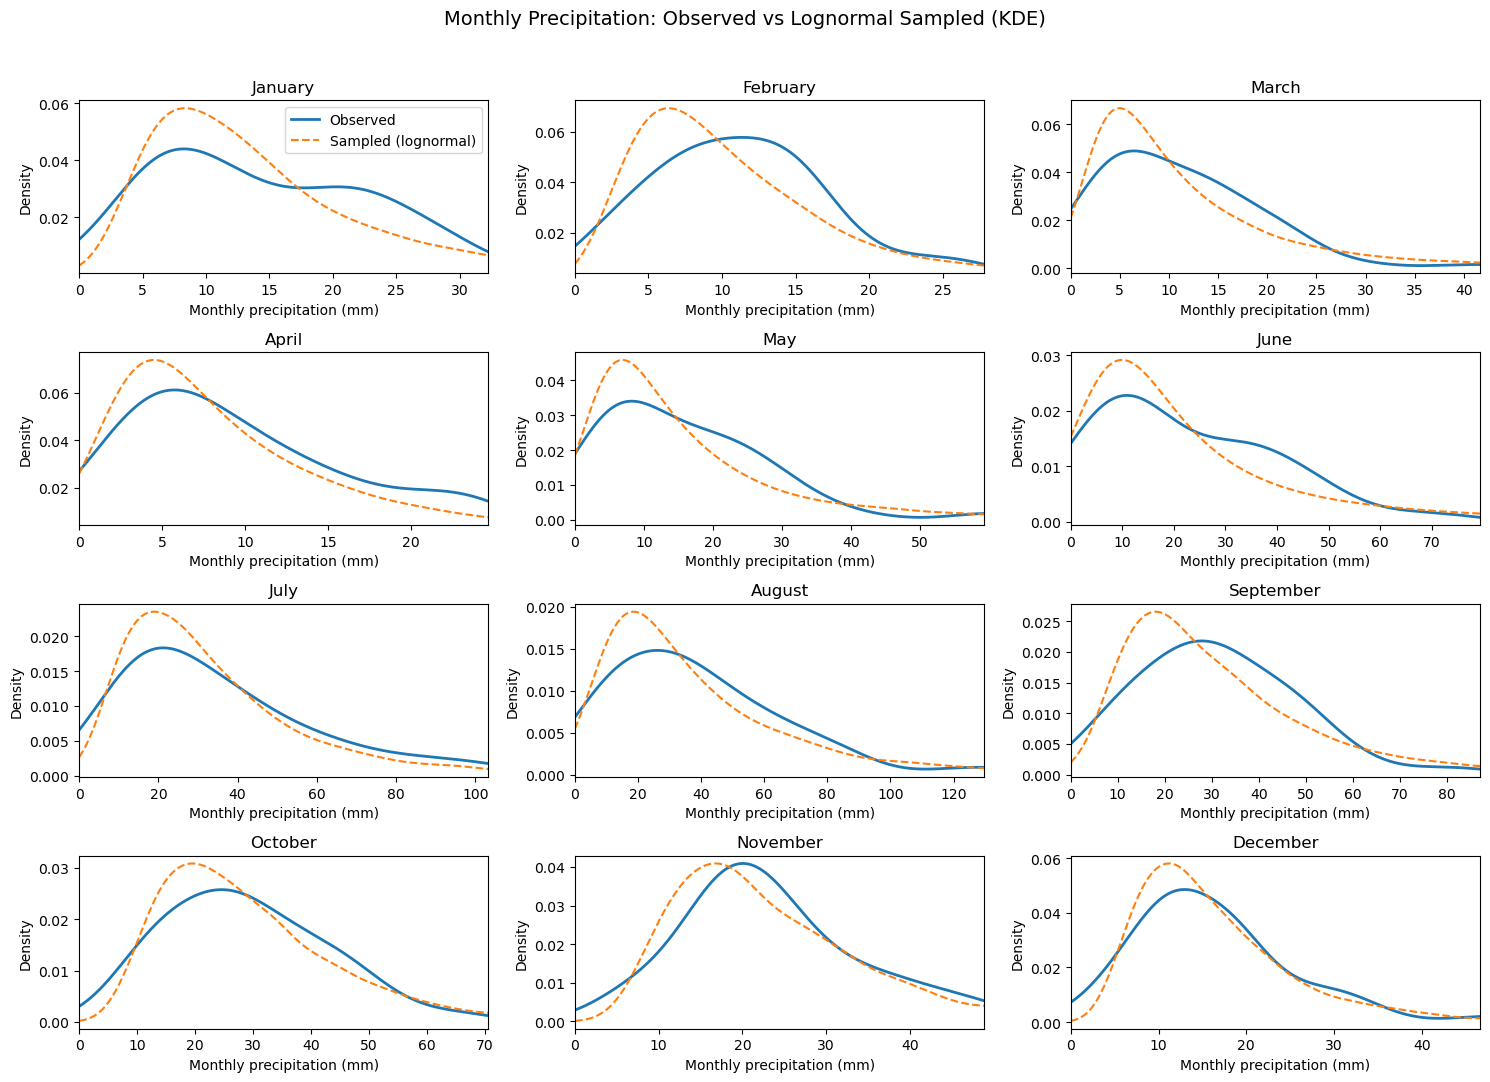

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    samp = precip_samples_lognorm[:, i]

    xmax = np.percentile(obs, 99)
    xgrid = np.linspace(0, xmax, 300)

    obs_kde = kde_1d(obs, xgrid)
    samp_kde = kde_1d(samp, xgrid)

    ax = axes[i]
    ax.plot(xgrid, obs_kde, label="Observed", linewidth=2)
    ax.plot(xgrid, samp_kde, label="Sampled (lognormal)", linestyle="--")

    ax.set_xlim(0, xmax)
    ax.set_title(month_name)
    ax.set_xlabel("Monthly precipitation (mm)")
    ax.set_ylabel("Density")

    if i == 0:
        ax.legend()

plt.suptitle(
    "Monthly Precipitation: Observed vs Lognormal Sampled (KDE)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Check against Normal

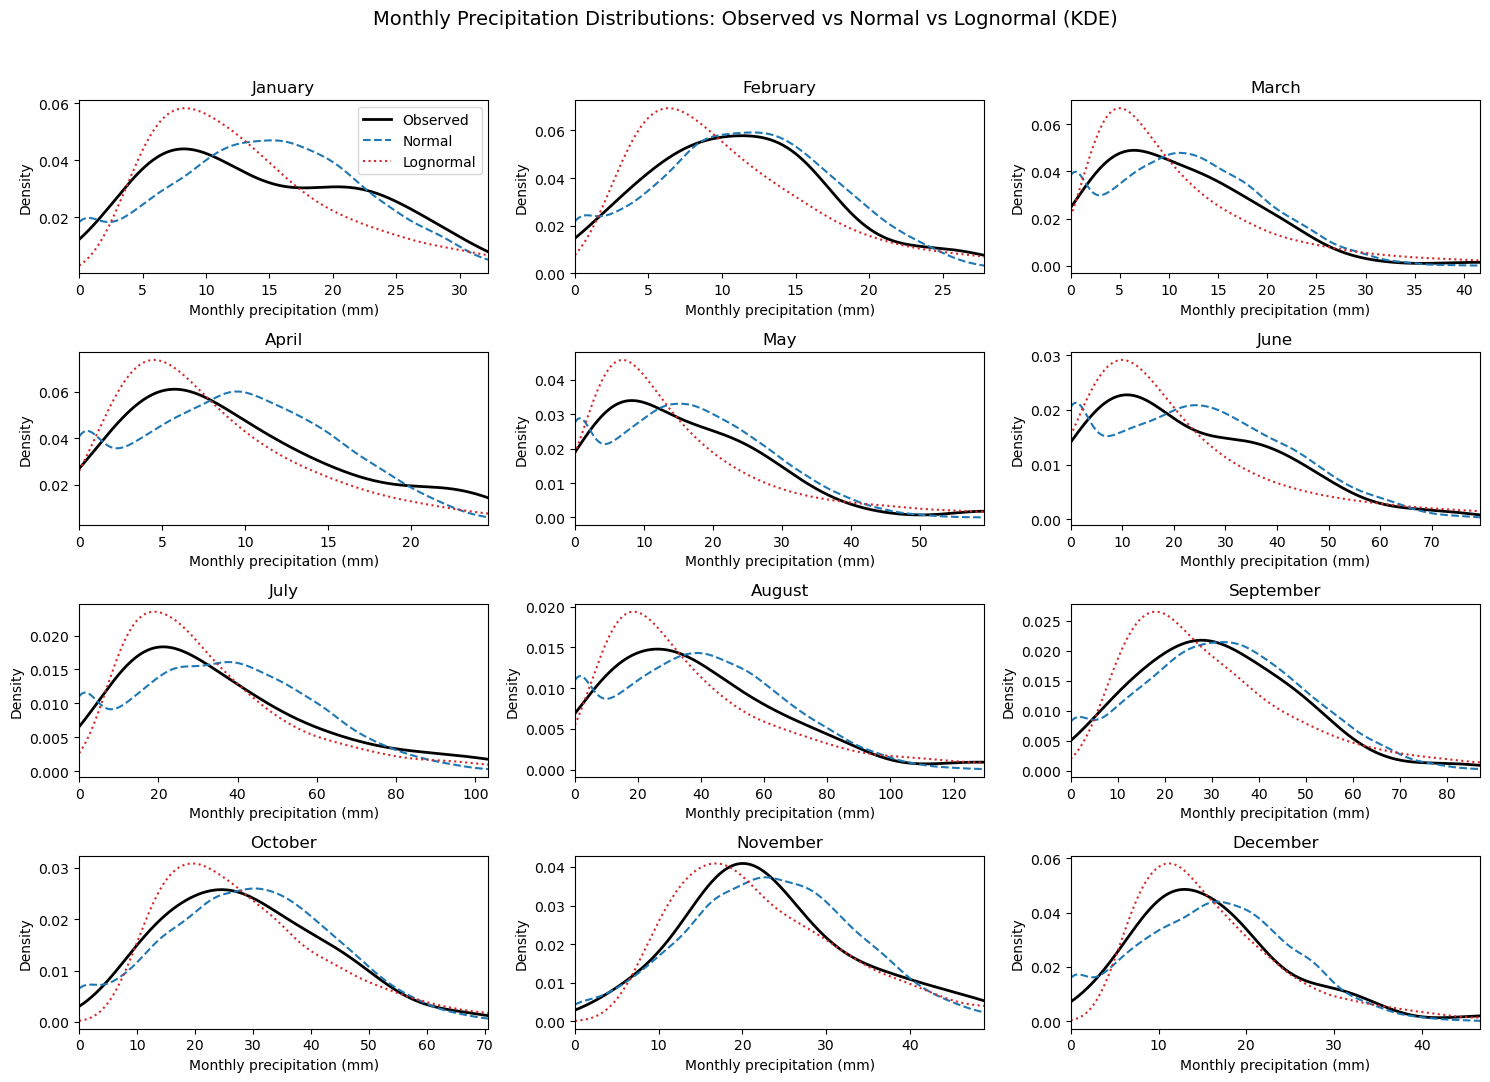

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    # Observed data
    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    # Sampled data
    samp_norm = precip_samples[:, i]
    samp_logn = precip_samples_lognorm[:, i]

    # X-axis range based on observed distribution
    xmax = np.percentile(obs, 99)
    xgrid = np.linspace(0, xmax, 300)

    # KDEs
    obs_kde = kde_1d(obs, xgrid)
    norm_kde = kde_1d(samp_norm, xgrid)
    logn_kde = kde_1d(samp_logn, xgrid)

    ax = axes[i]
    ax.plot(xgrid, obs_kde, color="black", linewidth=2, label="Observed")
    ax.plot(xgrid, norm_kde, linestyle="--", color="tab:blue", label="Normal")
    ax.plot(xgrid, logn_kde, linestyle=":", color="tab:red", label="Lognormal")

    ax.set_xlim(0, xmax)
    ax.set_title(month_name)
    ax.set_xlabel("Monthly precipitation (mm)")
    ax.set_ylabel("Density")

    if i == 0:
        ax.legend()

plt.suptitle(
    "Monthly Precipitation Distributions: Observed vs Normal vs Lognormal (KDE)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [15]:
precip_compare = []

for i in range(12):
    month = i + 1

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    samp_norm = precip_samples[:, i]
    samp_logn = precip_samples_lognorm[:, i]

    precip_compare.append({
        "month": month,

        # Means
        "obs_mean": obs.mean(),
        "norm_mean": samp_norm.mean(),
        "logn_mean": samp_logn.mean(),

        # Medians
        "obs_p50": np.percentile(obs, 50),
        "norm_p50": np.percentile(samp_norm, 50),
        "logn_p50": np.percentile(samp_logn, 50),

        # Upper tail
        "obs_p90": np.percentile(obs, 90),
        "norm_p90": np.percentile(samp_norm, 90),
        "logn_p90": np.percentile(samp_logn, 90),
    })

precip_compare_df = pd.DataFrame(precip_compare)
precip_compare_df

,month,obs_mean,norm_mean,logn_mean,obs_p50,norm_p50,logn_p50,obs_p90,norm_p90,logn_p90
0,1,14.646429,14.846166,15.074000,12.70,14.771214,12.187420,26.01,25.490305,28.628014
1,2,11.703571,11.788748,12.374180,11.25,11.688492,9.573738,20.05,20.142814,24.321575
2,3,11.388095,11.777714,12.212923,9.45,11.359167,8.401677,21.34,22.395285,25.820113
3,4,9.832143,9.957625,11.167898,7.90,9.671214,7.326151,21.48,18.503853,23.187970
4,5,15.879518,16.697650,17.612584,13.10,16.022392,11.313820,28.98,32.091861,38.038018
5,6,23.610843,24.803614,26.752422,17.00,23.813940,15.553739,46.60,48.626130,59.207310
6,7,35.503571,36.197433,35.670592,28.00,35.435150,27.865178,71.46,66.371724,68.672100
7,8,39.271429,40.053125,42.178810,31.20,39.018215,29.386165,76.07,75.450493,85.182252
8,9,32.025000,32.407216,33.107315,29.65,31.991181,26.281391,51.89,55.839825,62.167349
9,10,29.652381,29.643399,30.111227,27.35,29.502370,26.293753,46.69,48.799867,51.834277


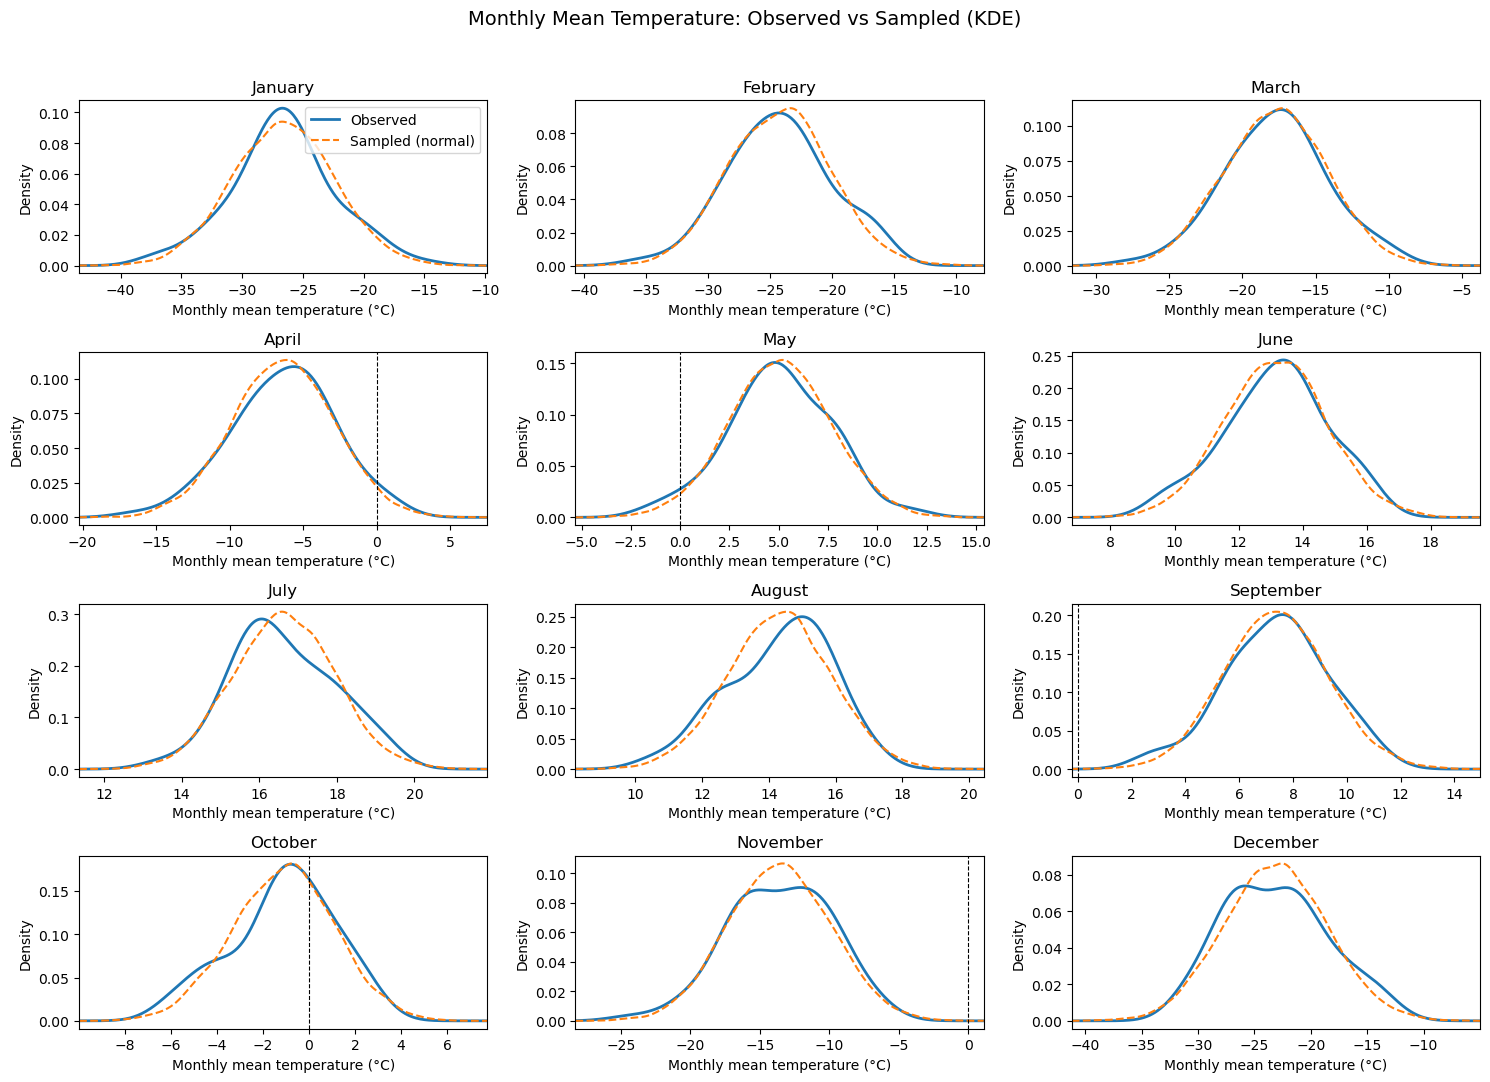

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "temp_mean_C"
    ].dropna()

    samp = temp_samples[:, i]

    mu = obs.mean()
    sigma = obs.std()

    xmin = mu - 4 * sigma
    xmax = mu + 4 * sigma

    xgrid = np.linspace(xmin, xmax, 300)

    obs_kde = kde_1d(obs, xgrid)
    samp_kde = kde_1d(samp, xgrid)

    ax = axes[i]
    ax.plot(xgrid, obs_kde, label="Observed", linewidth=2)
    ax.plot(xgrid, samp_kde, label="Sampled (normal)", linestyle="--")

    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)

    ax.set_xlim(xmin, xmax)
    ax.set_title(month_name)
    ax.set_xlabel("Monthly mean temperature (°C)")
    ax.set_ylabel("Density")

    if i == 0:
        ax.legend()

plt.suptitle(
    "Monthly Mean Temperature: Observed vs Sampled (KDE)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Check if the distributions are representative 

In [17]:
precip_metrics = []

for i in range(12):
    month = i + 1

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    samp = precip_samples_lognorm[:, i]

    metrics = {
        "month": month,
        "obs_mean": obs.mean(),
        "samp_mean": samp.mean(),
        "obs_std": obs.std(),
        "samp_std": samp.std(),
        "obs_p10": np.percentile(obs, 10),
        "samp_p10": np.percentile(samp, 10),
        "obs_p50": np.percentile(obs, 50),
        "samp_p50": np.percentile(samp, 50),
        "obs_p90": np.percentile(obs, 90),
        "samp_p90": np.percentile(samp, 90),
    }

    precip_metrics.append(metrics)

precip_metrics_df = pd.DataFrame(precip_metrics)
precip_metrics_df

,month,obs_mean,samp_mean,obs_std,samp_std,obs_p10,samp_p10,obs_p50,samp_p50,obs_p90,samp_p90
0,1,14.646429,15.074000,8.520046,10.860235,5.33,5.291085,12.70,12.187420,26.01,28.628014
1,2,11.703571,12.374180,6.548714,10.023823,3.93,3.819053,11.25,9.573738,20.05,24.321575
2,3,11.388095,12.212923,8.567400,12.549145,2.80,2.631905,9.45,8.401677,21.34,25.820113
3,4,9.832143,11.167898,6.854445,12.790636,2.36,2.377532,7.90,7.326151,21.48,23.187970
4,5,15.879518,17.612584,12.129110,21.068664,3.66,3.372546,13.10,11.313820,28.98,38.038018
5,6,23.610843,26.752422,19.719020,38.371192,3.72,4.292484,17.00,15.553739,46.60,59.207310
6,7,35.503571,35.670592,24.472933,29.022173,10.82,10.858198,28.00,27.865178,71.46,68.672100
7,8,39.271429,42.178810,28.534463,44.875951,8.49,9.889880,31.20,29.386165,76.07,85.182252
8,9,32.025000,33.107315,18.189656,25.877278,11.29,11.071912,29.65,26.281391,51.89,62.167349
9,10,29.652381,30.111227,15.237766,17.272524,11.73,13.028054,27.35,26.293753,46.69,51.834277


In [18]:
temp_metrics = []

for i in range(12):
    month = i + 1

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "temp_mean_C"
    ].dropna()

    samp = temp_samples[:, i]

    metrics = {
        "month": month,
        "obs_mean": obs.mean(),
        "samp_mean": samp.mean(),
        "obs_std": obs.std(),
        "samp_std": samp.std(),
        "obs_p10": np.percentile(obs, 10),
        "samp_p10": np.percentile(samp, 10),
        "obs_p50": np.percentile(obs, 50),
        "samp_p50": np.percentile(samp, 50),
        "obs_p90": np.percentile(obs, 90),
        "samp_p90": np.percentile(samp, 90),
    }

    temp_metrics.append(metrics)

temp_metrics_df = pd.DataFrame(temp_metrics)
temp_metrics_df


,month,obs_mean,samp_mean,obs_std,samp_std,obs_p10,samp_p10,obs_p50,samp_p50,obs_p90,samp_p90
0,1,-26.619527,-26.612984,4.199473,4.213775,-31.841935,-32.018028,-26.630645,-26.602505,-20.790000,-21.254444
1,2,-24.212752,-24.224243,4.114606,4.115769,-28.949643,-29.492874,-23.865456,-24.159850,-17.821429,-18.965340
2,3,-17.708455,-17.737744,3.487436,3.506304,-22.006452,-22.355125,-17.619355,-17.666808,-13.193548,-13.244568
3,4,-6.357527,-6.372523,3.467832,3.453470,-10.762667,-10.854528,-6.286667,-6.359786,-2.435667,-1.945930
4,5,5.042976,5.075503,2.587179,2.590276,1.832258,1.811911,5.006452,5.074492,8.160000,8.391584
5,6,13.165437,13.158175,1.593175,1.604079,11.132667,11.094675,13.156667,13.161929,15.382000,15.225505
6,7,16.617361,16.631606,1.315769,1.310083,15.125484,14.940157,16.467742,16.633712,18.410323,18.275357
7,8,14.320622,14.312812,1.527542,1.538623,12.301935,12.346465,14.525806,14.330352,16.136774,16.296575
8,9,7.364951,7.362458,1.897107,1.928854,5.115333,4.906019,7.540000,7.355385,9.860379,9.831269
9,10,-1.121027,-1.104339,2.215901,2.223397,-4.350323,-4.012000,-1.032258,-1.041948,1.591935,1.703470


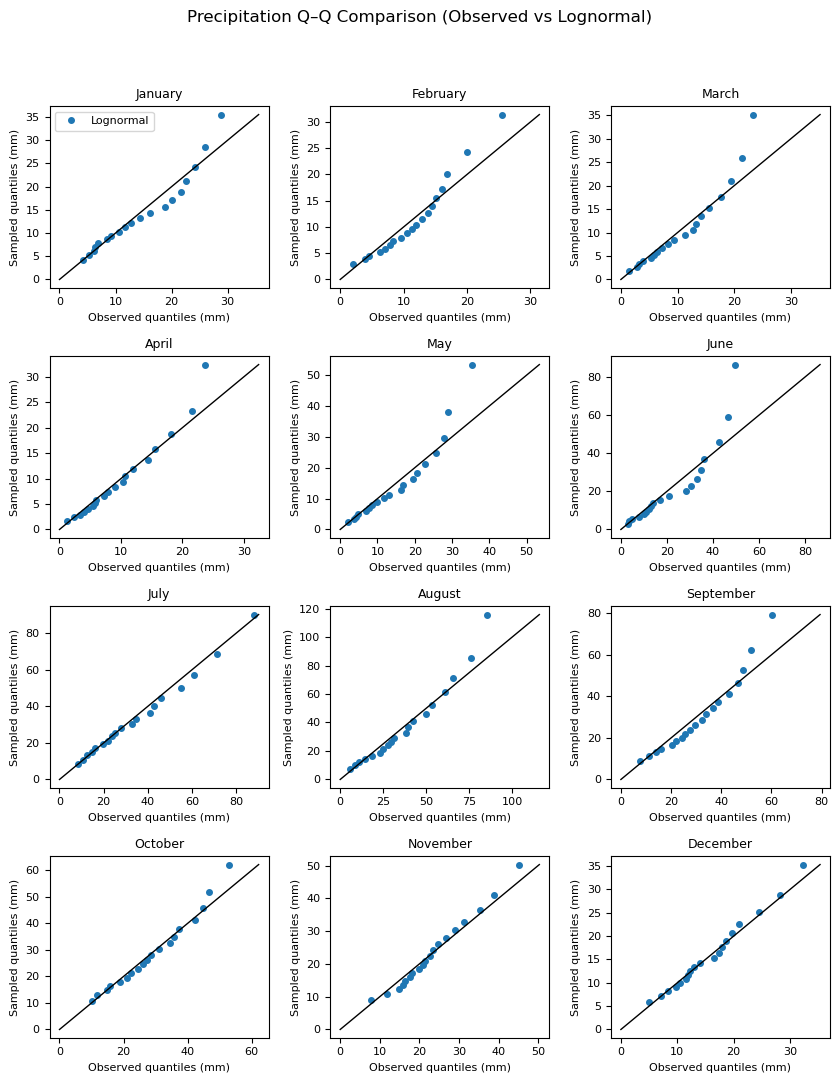

In [28]:
quantiles = np.linspace(0.05, 0.95, 19)

fig, axes = plt.subplots(4, 3, figsize=(8.5, 11))
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "precip_mm"
    ].dropna()

    q_obs = np.quantile(obs, quantiles)
    q_logn = np.quantile(precip_samples_lognorm[:, i], quantiles)

    lim_max = max(q_obs.max(), q_logn.max())
    lim = [0, lim_max]

    ax = axes[i]
    ax.plot(
        q_obs,
        q_logn,
        "o",
        markersize=4,
        label="Lognormal",
    )
    ax.plot(lim, lim, "k-", linewidth=1)

    ax.set_title(month_name, fontsize=9)
    ax.set_xlabel("Observed quantiles (mm)", fontsize=8)
    ax.set_ylabel("Sampled quantiles (mm)", fontsize=8)

    ax.tick_params(labelsize=8)

    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    "Precipitation Q–Q Comparison (Observed vs Lognormal)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

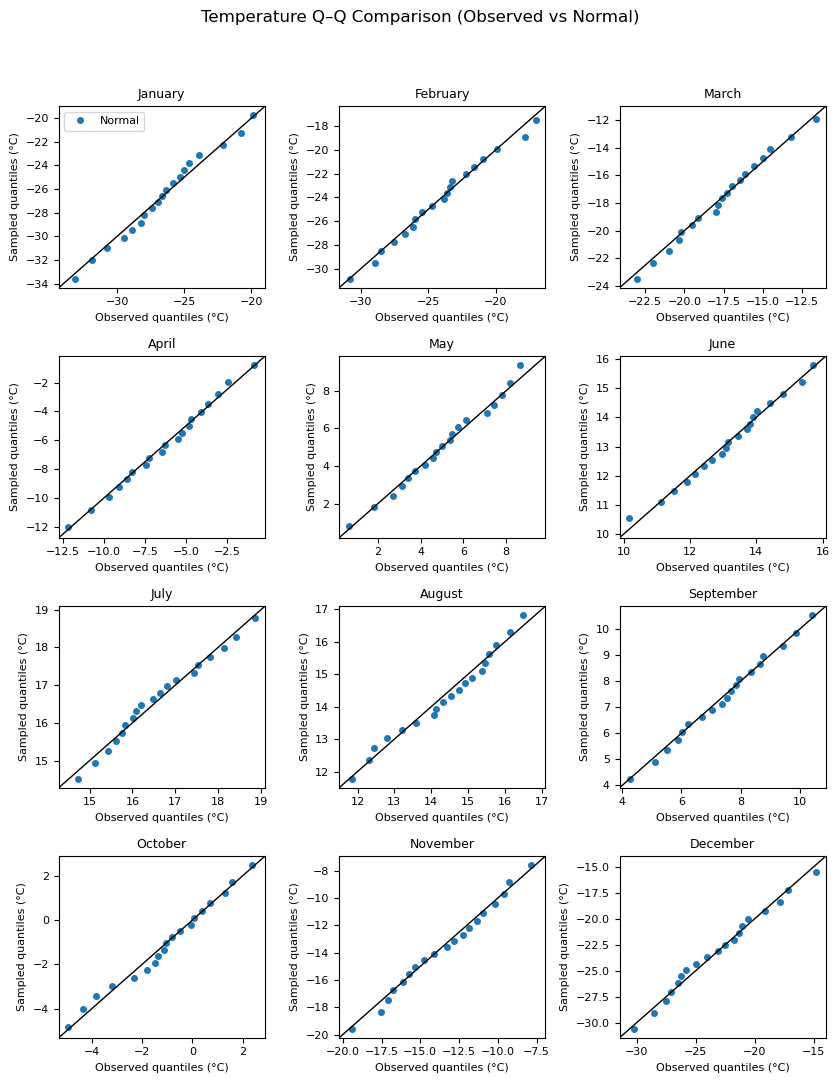

In [26]:
quantiles = np.linspace(0.05, 0.95, 19)

fig, axes = plt.subplots(4, 3, figsize=(8.5, 11))
axes = axes.flatten()

for i in range(12):
    month = i + 1
    month_name = monthly_climatology.loc[i, "month_name"]

    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month, "temp_mean_C"
    ].dropna()

    q_obs = np.quantile(obs, quantiles)
    q_norm = np.quantile(temp_samples[:, i], quantiles)

    # Define symmetric limits per month
    lim_min = min(q_obs.min(), q_norm.min())
    lim_max = max(q_obs.max(), q_norm.max())
    pad = 0.05 * (lim_max - lim_min)
    lim = [lim_min - pad, lim_max + pad]

    ax = axes[i]
    ax.plot(
        q_obs,
        q_norm,
        "o",
        markersize=4,
        label="Normal",
    )
    ax.plot(lim, lim, "k-", linewidth=1)

    ax.set_xlim(lim)
    ax.set_ylim(lim)

    ax.set_title(month_name, fontsize=9)
    ax.set_xlabel("Observed quantiles (°C)", fontsize=8)
    ax.set_ylabel("Sampled quantiles (°C)", fontsize=8)
    ax.tick_params(labelsize=8)

    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    "Temperature Q–Q Comparison (Observed vs Normal)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Output the distribution parameters for Excel

In [29]:
precip_params = []

for month in range(1, 13):
    obs = monthly_by_year.loc[
        (monthly_by_year["month"] == month) &
        (monthly_by_year["precip_mm"] > 0),
        "precip_mm"
    ].dropna()

    ln_obs = np.log(obs)

    precip_params.append({
        "month": month,
        "month_name": monthly_climatology.loc[month - 1, "month_name"],
        "precip_logn_mu": ln_obs.mean(),
        "precip_logn_sigma": ln_obs.std(),
    })

precip_params_df = pd.DataFrame(precip_params)
precip_params_df

,month,month_name,precip_logn_mu,precip_logn_sigma
0,1,January,2.506917,0.664650
1,2,February,2.254787,0.737268
2,3,March,2.115755,0.890323
3,4,April,1.994196,0.909057
4,5,May,2.439460,0.944587
5,6,June,2.753869,1.030742
6,7,July,3.328889,0.726001
7,8,August,3.371173,0.854308
8,9,September,3.277796,0.684423
9,10,October,3.255858,0.539647


In [30]:
temp_params = []

for month in range(1, 13):
    obs = monthly_by_year.loc[
        monthly_by_year["month"] == month,
        "temp_mean_C"
    ].dropna()

    temp_params.append({
        "month": month,
        "month_name": monthly_climatology.loc[month - 1, "month_name"],
        "temp_mean_C": obs.mean(),
        "temp_std_C": obs.std(),
    })

temp_params_df = pd.DataFrame(temp_params)
temp_params_df

,month,month_name,temp_mean_C,temp_std_C
0,1,January,-26.619527,4.199473
1,2,February,-24.212752,4.114606
2,3,March,-17.708455,3.487436
3,4,April,-6.357527,3.467832
4,5,May,5.042976,2.587179
5,6,June,13.165437,1.593175
6,7,July,16.617361,1.315769
7,8,August,14.320622,1.527542
8,9,September,7.364951,1.897107
9,10,October,-1.121027,2.215901
